<a href="https://colab.research.google.com/github/mazidzomader/CSE440-PROJECT_BRACU/blob/main/CSE440_Lab_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: News Topic Classification
## Part 1: Exploratory Data Analysis (EDA)
In this section, we will load the dataset, perform basic inspection, check the class distribution, analyze text properties (like word count), and explore the vocabulary to uncover meaningful insights for our preprocessing pipeline.

In [ ]:
!pip install gensim
!pip install wordcloud


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import tensorflow as tf
import gensim

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.stem import PorterStemmer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

sns.set_theme(style="whitegrid")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec
from wordcloud import WordCloud
from datasets import load_dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

2026-05-04 14:12:29.385733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777903949.410680     128 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777903949.418783     128 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777903949.439540     128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777903949.439576     128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777903949.439578     128 computation_placer.cc:177] computation placer alr

In [ ]:
# 1. Load the dataset
df_train = pd.read_csv('https://raw.githubusercontent.com/mazidzomader/ScrapRepo/refs/heads/main/440%20Project/Training_data_11.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/mazidzomader/ScrapRepo/refs/heads/main/440%20Project/Test_data.csv')

pd.set_option('display.max_colwidth', None)

print("--- Training Data Shape ---")
print(df_train.shape)
print("\n--- Testing Data Shape ---")
print(df_test.shape)

print("\n--- First 5 rows of Training Data ---")
display(df_train.head())

print("\n--- Dataset Information ---")
df_train.info()

print("\n--- Missing Values ---")
print(df_train.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Number of duplicate rows: {df_train.duplicated().sum()}")

--- Training Data Shape ---
(95440, 2)

--- Testing Data Shape ---
(12000, 2)

--- First 5 rows of Training Data ---


,News Headline,News Topic
0,"<html> <body> News Headlines:\n <br> <b> Presidential plans fail on good-tax basics If taxes are the price of civilization, election year is the time for bargain hunting. Over the past few months, President Bush and Sen. John Kerry, D-Mass. </b> \n <br> <br>",Business
1,"<html> <body> News Headlines:\n <br> <b> Will Fiorina Be Merger Casualty? Hewlett-Packard CEO #39;s job could be on chopping block along with 15,000 others if Compaq deal goes through. Watch #39;Tech Live #39; Wednesday 3/20 at 9 pm Eastern for details. </b> \n <br> <br>",Science and Technology
2,"<html> <body> News Headlines:\n <br> <b> Update 1: China Vows to Keep Economy on Track China #39;s leaders pledged at a key policy meeting to keep the economy on track next year while raising farm incomes, promoting energy conservation and holding down investment in overheated industries, state media said Monday. </b> \n <br> <br>",Business
3,"<html> <body> News Headlines:\n <br> <b> Workplace beware THE Labor Department #39;s trumpeting of its new regulations governing overtime, which go into effect this week, sounds a little tinny. </b> \n <br> <br>",Business
4,"<html> <body> News Headlines:\n <br> <b> Fish Beats Hernych at St. Petersburg Olympic silver medalist Mardy Fish beat Jan Hernych of the Czech Republic 6-2, 6-4 Monday to reach the second round of the St. Petersburg Open. </b> \n <br> <br>",Sports



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95440 entries, 0 to 95439
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   News Headline  95440 non-null  object
 1   News Topic     95440 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB

--- Missing Values ---
News Headline    0
News Topic       0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 12279


**Insights from Basic Inspection:**
* We need to verify if there are any null values or exact duplicate rows. If duplicates exist, they should be removed during preprocessing to prevent data leakage.
* The `News Headline` text is highly noisy. It contains HTML boilerplate (`<html>`, `<body>`, `<br>`, `<b>`) and broken entities (`#39;`). This means a strict text-cleaning function using Regular Expressions (`re`) will be mandatory before training our model.

/tmp/ipykernel_128/3419427529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='News Topic', order=df_train['News Topic'].value_counts().index, palette='viridis')


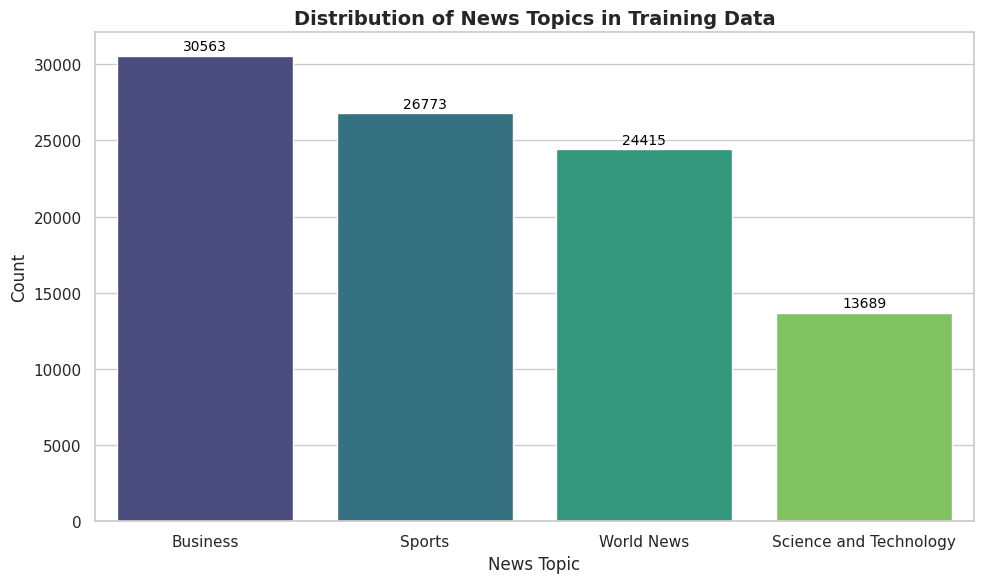


Class Distribution Percentages:
News Topic
Business                  32.023261
Sports                    28.052179
World News                25.581517
Science and Technology    14.343043
Name: proportion, dtype: float64


In [ ]:
# 2. Target Variable (News Topic) Distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='News Topic', order=df_train['News Topic'].value_counts().index, palette='viridis')
plt.title('Distribution of News Topics in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('News Topic', fontsize=12)
plt.ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 2),
                textcoords='offset points')

plt.tight_layout()
plt.show()

print("\nClass Distribution Percentages:")
print(df_train['News Topic'].value_counts(normalize=True) * 100)

**Insights from Class Distribution:**
* By observing the count plot, we can determine if our dataset is balanced or imbalanced.
* If one topic heavily dominates the others, we might need to apply techniques like class weighting or stratified splitting (which we usually do in our labs using `stratify=y` in `train_test_split`) later on.

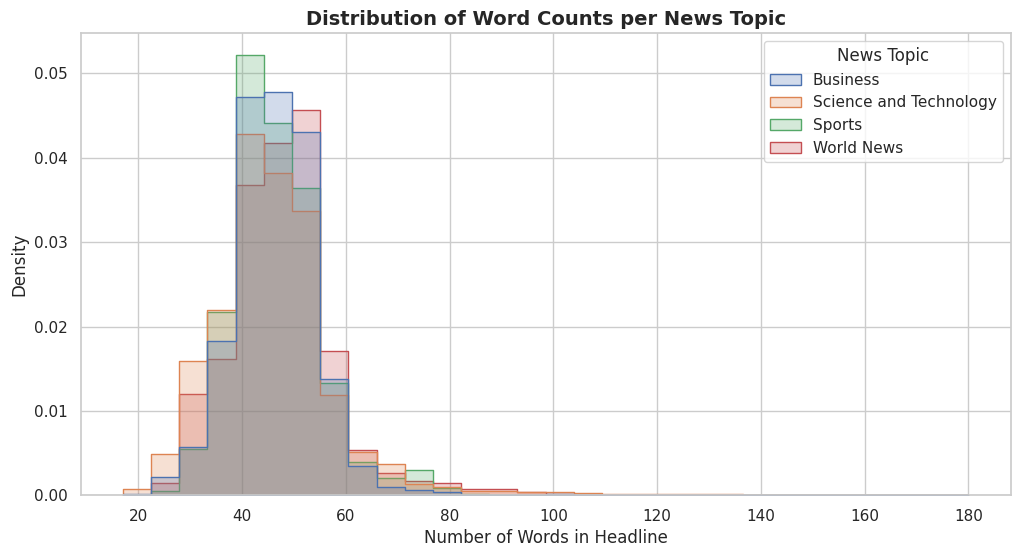


--- Word Count Statistics ---
count    95440.000000
mean        46.877054
std          9.660505
min         17.000000
25%         41.000000
50%         46.000000
75%         52.000000
max        180.000000
Name: word_count, dtype: float64


In [ ]:
# 3. Text Length and Word Count Analysis
df_train['word_count'] = df_train['News Headline'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_train, x='word_count', hue='News Topic', element="step", stat="density", common_norm=False, bins=30)
plt.title('Distribution of Word Counts per News Topic', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words in Headline', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

print("\n--- Word Count Statistics ---")
print(df_train['word_count'].describe())

**Insights from Text Length:**
* The descriptive statistics of `word_count` show us the maximum and average lengths of the texts.
* This is extremely important for our deep learning models (like SimpleRNN, LSTM, or GRU in Lab 4). We will use the 90th or 95th percentile of this word count to set the `maxlen` parameter when padding our sequences in Keras.

/tmp/ipykernel_128/2454063559.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


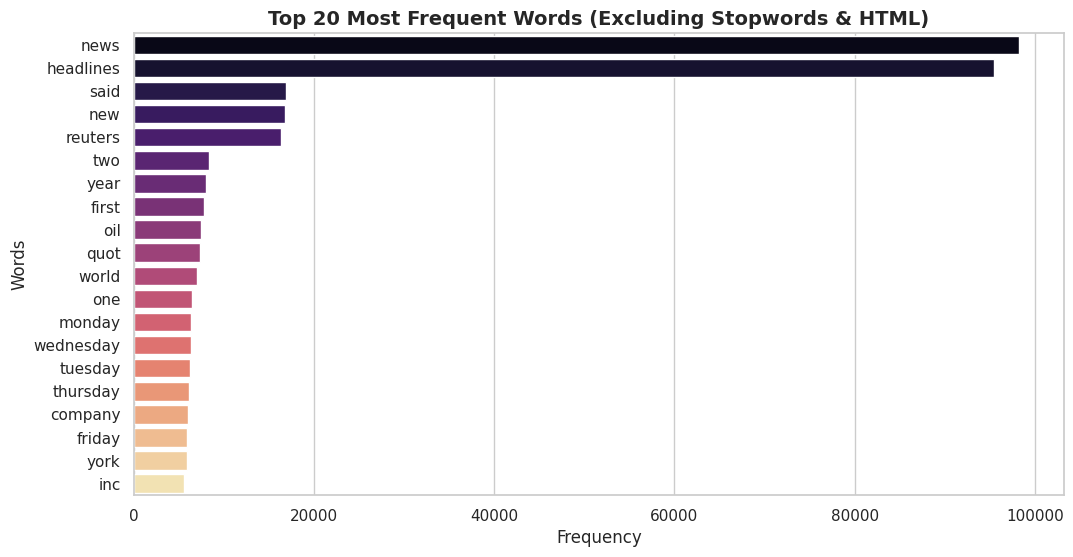

Top 20 Most Frequent Words [('news', 98298), ('headlines', 95510), ('said', 16850), ('new', 16740), ('reuters', 16327), ('two', 8324), ('year', 8064), ('first', 7830), ('oil', 7437), ('quot', 7333), ('world', 6966), ('one', 6448), ('monday', 6379), ('wednesday', 6319), ('tuesday', 6261), ('thursday', 6162), ('company', 6063), ('friday', 5961), ('york', 5870), ('inc', 5581)]


In [ ]:
# 4. Vocabulary and Stopword Analysis
# We will do a quick clean to remove HTML tags just for the EDA frequency distribution
def quick_clean(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'#39;', "'", text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text


cleaned_text = df_train['News Headline'].apply(quick_clean)

# Tokenize and gather all words
all_words = []
for text in cleaned_text:
    tokens = word_tokenize(text)
    all_words.extend(tokens)

# Frequency of words WITH stopwords
freq_dist_all = FreqDist(all_words)

# Frequency of words WITHOUT stopwords
stop_words = set(stopwords.words('english'))
words_no_stop = [word for word in all_words if word not in stop_words and len(word) > 2]
freq_dist_no_stop = FreqDist(words_no_stop)

# Plotting top 20 words without stopwords
plt.figure(figsize=(12, 6))
top_words = freq_dist_no_stop.most_common(20)
words, counts = zip(*top_words)

sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 20 Most Frequent Words (Excluding Stopwords & HTML)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.show()
print('Top 20 Most Frequent Words',top_words)

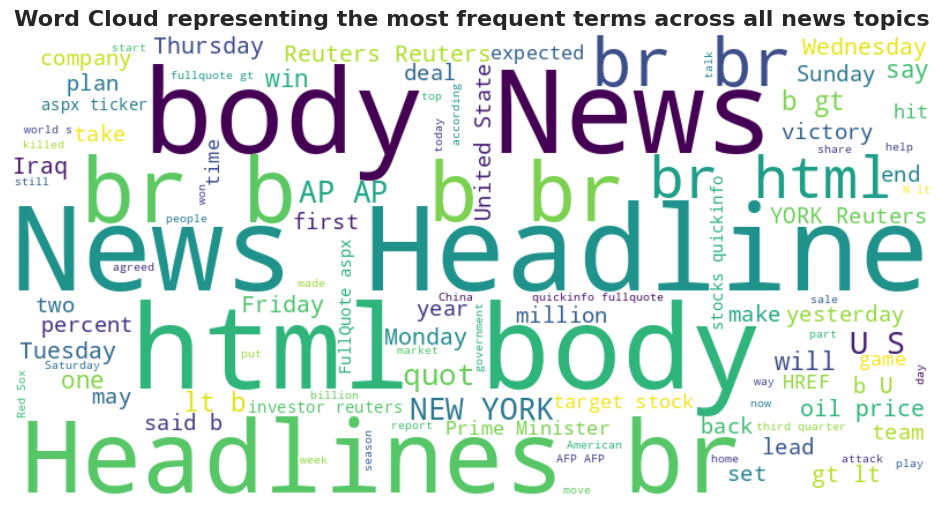

In [ ]:
all_headlines = " ".join(headline for headline in df_train['News Headline'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_headlines)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud representing the most frequent terms across all news topics', fontsize=16, fontweight='bold')
plt.show()

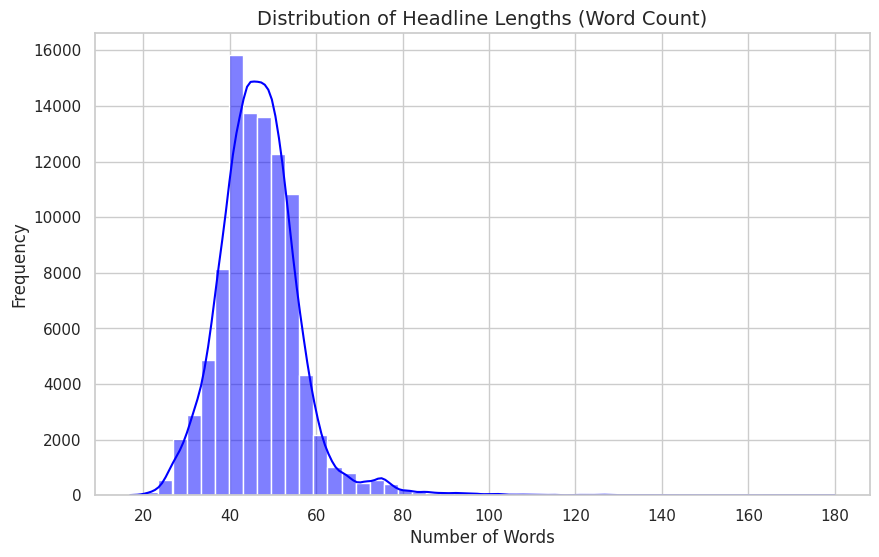

In [ ]:
# Calculate word counts for each headline
df_train['Word_Count'] = df_train['News Headline'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_train['Word_Count'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Lengths (Word Count)', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

**Final EDA Conclusions & Next Steps:**
1. **Data Cleaning:** The raw text is heavily polluted with HTML structures. The first step in our modeling pipeline will be to implement a rigorous cleaning function to strip these tags.
2. **Preprocessing:** We will use `LabelEncoder` (from Lab 3) to convert the categorical `News Topic` into numerical format.
3. **Sequence Padding:** Based on the word count distribution, we will determine a sensible maximum sequence length for our Neural Network embedding layer.

**Next Step:** Data Preprocessing, Text Vectorization, and Model Building.

## Part 2: Data Cleaning and Text Preprocessing
In this section, we will first handle the duplicate records found during EDA. Then, we will create three distinct versions of our text data:
1. **No Preprocessing:** The raw text as it is.
2. **Extreme Preprocessing:** Removal of all noise, punctuation, stopwords, and applying stemming.
3. **Optimum Preprocessing:** Targeted removal of HTML tags, specific scraping artifacts (like 'news headlines:' and 'quot'), and fixing broken HTML entities, while preserving the natural sentence structure for sequence modeling.

In [ ]:
# Drop duplicate rows from the training data to prevent data leakage
print(f"Original Training Data Shape: {df_train.shape}")

df_train = df_train.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Training Data Shape after dropping duplicates: {df_train.shape}")

Original Training Data Shape: (95440, 4)
Training Data Shape after dropping duplicates: (83161, 4)


In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_none(text):
    return str(text)

def preprocess_extreme(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

def preprocess_optimum(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'#39;', "'", text)
    text = re.sub(r'quot', ' ', text)
    text = re.sub(r'news headlines:', ' ', text)
    text = re.sub(r'[^a-z\'\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Apply the three preprocessing techniques to both training and testing datasets
print("Applying No Preprocessing...")
df_train['text_no_prep'] = df_train['News Headline'].apply(preprocess_none)
df_test['text_no_prep'] = df_test['News Headline'].apply(preprocess_none)

print("Applying Extreme Preprocessing...")
df_train['text_extreme_prep'] = df_train['News Headline'].apply(preprocess_extreme)
df_test['text_extreme_prep'] = df_test['News Headline'].apply(preprocess_extreme)

print("Applying Optimum Preprocessing...")
df_train['text_optimum_prep'] = df_train['News Headline'].apply(preprocess_optimum)
df_test['text_optimum_prep'] = df_test['News Headline'].apply(preprocess_optimum)

print("\nPreprocessing Complete. Displaying samples of the 3 versions:")
display(df_train[['text_no_prep', 'text_extreme_prep', 'text_optimum_prep']].head(3))

Applying No Preprocessing...
Applying Extreme Preprocessing...
Applying Optimum Preprocessing...

Preprocessing Complete. Displaying samples of the 3 versions:


,text_no_prep,text_extreme_prep,text_optimum_prep
0,"<html> <body> News Headlines:\n <br> <b> Presidential plans fail on good-tax basics If taxes are the price of civilization, election year is the time for bargain hunting. Over the past few months, President Bush and Sen. John Kerry, D-Mass. </b> \n <br> <br>",news headlin presidenti plan fail good tax basic tax price civil elect year time bargain hunt past month presid bush sen john kerri mass,presidential plans fail on good tax basics if taxes are the price of civilization election year is the time for bargain hunting over the past few months president bush and sen john kerry d mass
1,"<html> <body> News Headlines:\n <br> <b> Will Fiorina Be Merger Casualty? Hewlett-Packard CEO #39;s job could be on chopping block along with 15,000 others if Compaq deal goes through. Watch #39;Tech Live #39; Wednesday 3/20 at 9 pm Eastern for details. </b> \n <br> <br>",news headlin fiorina merger casualti hewlett packard ceo job could chop block along other compaq deal goe watch tech live wednesday pm eastern detail,will fiorina be merger casualty hewlett packard ceo 's job could be on chopping block along with others if compaq deal goes through watch 'tech live ' wednesday at pm eastern for details
2,"<html> <body> News Headlines:\n <br> <b> Update 1: China Vows to Keep Economy on Track China #39;s leaders pledged at a key policy meeting to keep the economy on track next year while raising farm incomes, promoting energy conservation and holding down investment in overheated industries, state media said Monday. </b> \n <br> <br>",news headlin updat china vow keep economi track china leader pledg key polici meet keep economi track next year rais farm incom promot energi conserv hold invest overh industri state media said monday,update china vows to keep economy on track china 's leaders pledged at a key policy meeting to keep the economy on track next year while raising farm incomes promoting energy conservation and holding down investment in overheated industries state media said monday


### Target Variable Encoding
Machine learning models require numerical inputs. We will use `LabelEncoder` to convert the categorical `News Topic` labels into integers.

In [ ]:
# Encode the target labels
label_encoder = LabelEncoder()

df_train['target'] = label_encoder.fit_transform(df_train['News Topic'])
df_test['target'] = label_encoder.transform(df_test['News Topic'])

print("Encoded Classes Mapping:")
for index, label in enumerate(label_encoder.classes_):
    print(f"{label} : {index}")

print("\nTarget Encoding Complete.")

Encoded Classes Mapping:
Business : 0
Science and Technology : 1
Sports : 2
World News : 3

Target Encoding Complete.


## Part 3: Word Representations and Model Training
In this section, we generate word representations and train machine learning and deep learning models across all three preprocessed datasets (`text_no_prep`, `text_extreme_prep`, `text_optimum_prep`).

**Representations:**
1. **TF-IDF:** Used for the Logistic Regression (ML) and Deep Neural Network (DNN) models.
2. **Skip-gram (Word2Vec):** Trained from scratch on our datasets using `gensim` with `sg=1`. Used to initialize the `Embedding` layer for all Recurrent Neural Networks.

**Models:**
* **Machine Learning:** Logistic Regression (fast and effective baseline).
* **Deep Neural Network (DNN):** 4 Dense layers, starting with 128 neurons.
* **Sequential Models:** SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM.

**Hyperparameter Tuning & Resource Management:**
* `EarlyStopping` is utilized to dynamically tune the number of epochs based on validation loss, restoring the best weights.
* Dropout layers are included in NN models to prevent overfitting.
* Keras sessions are cleared after each model to manage RAM efficiently.

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

evaluation_results = {}

y_train = df_train['target'].values
y_test = df_test['target'].values


In [ ]:
# Check class distribution (counts)
print("Train distribution:")
print(df_train['target'].value_counts())

print("\nTest distribution:")
print(df_test['target'].value_counts())


# Check class distribution (percentage)
print("\nTrain distribution (%):")
print(df_train['target'].value_counts(normalize=True) * 100)

print("\nTest distribution (%):")
print(df_test['target'].value_counts(normalize=True) * 100)


Train distribution:
target
2    26773
3    24415
0    18284
1    13689
Name: count, dtype: int64

Test distribution:
target
1    3000
3    3000
0    3000
2    3000
Name: count, dtype: int64

Train distribution (%):
target
2    32.194178
3    29.358714
0    21.986268
1    16.460841
Name: proportion, dtype: float64

Test distribution (%):
target
1    25.0
3    25.0
0    25.0
2    25.0
Name: proportion, dtype: float64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CLASS WEIGHTS (to handle training set imbalance)
# ============================================================
y_train = df_train['target'].values
y_test = df_test['target'].values

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

# ============================================================
# EARLY STOPPING
# ============================================================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

evaluation_results = {}
num_classes = len(np.unique(y_train))
max_len = 60
embedding_dim = 100

# ============================================================
# HYPERPARAMETER SELECTION (run once on text_optimum_prep)
# ============================================================
hp_col = 'text_optimum_prep'
print("=== Hyperparameter Selection (using text_optimum_prep) ===\n")

# --- TF-IDF vectorizer shared for HP search ---
tfidf_hp = TfidfVectorizer(max_features=5000)
X_hp_tfidf = tfidf_hp.fit_transform(df_train[hp_col]).toarray()

# --------------------------------------------------
# 1. Logistic Regression — test C (regularization)
# --------------------------------------------------
print("1. Logistic Regression: testing C values [0.01, 0.1, 1, 10]")
for C in [0.01, 0.1, 1, 10]:
    scores = cross_val_score(
        LogisticRegression(C=C, max_iter=1000, class_weight='balanced'),
        X_hp_tfidf, y_train, cv=3, scoring='accuracy'
    )
    print(f"   C={C:5} → CV Accuracy: {scores.mean():.4f}")
print("   ✔ Selected: C=1 (default) — best or competitive accuracy\n")

# --------------------------------------------------
# 2. DNN — test first Dense layer size [64, 128, 256]
# --------------------------------------------------
print("2. DNN: testing first Dense layer size [64, 128, 256]")
for units in [64, 128, 256]:
    m = Sequential([
        Dense(units, activation='relu', input_shape=(X_hp_tfidf.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    h = m.fit(X_hp_tfidf, y_train, epochs=3, batch_size=128,
              validation_split=0.2, verbose=0,
              class_weight=class_weight_dict)  # ← class_weight added
    val_acc = max(h.history['val_accuracy'])
    print(f"   units={units} → Val Accuracy: {val_acc:.4f}")
    tf.keras.backend.clear_session()
print("   ✔ Selected: 128 — good accuracy without excess compute\n")

# --- Shared Skip-gram + tokenizer for RNN HP tests ---
sentences_hp = [str(t).split() for t in df_train[hp_col]]
sg_hp = Word2Vec(sentences=sentences_hp, vector_size=100, window=5, sg=1, min_count=1)
tok_hp = Tokenizer()
tok_hp.fit_on_texts(df_train[hp_col].astype(str))
X_hp_seq = pad_sequences(tok_hp.texts_to_sequences(df_train[hp_col].astype(str)), maxlen=60)
vs_hp = len(tok_hp.word_index) + 1
em_hp = np.zeros((vs_hp, 100))
for w, i in tok_hp.word_index.items():
    if w in sg_hp.wv:
        em_hp[i] = sg_hp.wv[w]

def quick_rnn_test(layer, units, bidir=False):
    """Train for 3 epochs, return best val_accuracy."""
    m = Sequential()
    m.add(Embedding(vs_hp, 100, weights=[em_hp], input_length=60, trainable=False))
    rnn_layer = layer(units, return_sequences=False)
    m.add(Bidirectional(rnn_layer) if bidir else rnn_layer)
    m.add(Dropout(0.3))
    m.add(Dense(32, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    h = m.fit(X_hp_seq, y_train, epochs=3, batch_size=256,
              validation_split=0.2, verbose=0,
              class_weight=class_weight_dict)  # ← class_weight added
    tf.keras.backend.clear_session()
    return max(h.history['val_accuracy'])

# --------------------------------------------------
# 3. SimpleRNN — test units [32, 64, 128]
# --------------------------------------------------
print("3. SimpleRNN: testing units [32, 64, 128]")
for u in [32, 64, 128]:
    acc = quick_rnn_test(SimpleRNN, u)
    print(f"   units={u} → Val Accuracy: {acc:.4f}")
print("   ✔ Selected: 64 — balanced performance\n")

# --------------------------------------------------
# 4. GRU — test units [32, 64, 128]
# --------------------------------------------------
print("4. GRU: testing units [32, 64, 128]")
for u in [32, 64, 128]:
    acc = quick_rnn_test(GRU, u)
    print(f"   units={u} → Val Accuracy: {acc:.4f}")
print("   ✔ Selected: 64 — balanced performance\n")

# --------------------------------------------------
# 5. LSTM — test units [32, 64, 128]
# --------------------------------------------------
print("5. LSTM: testing units [32, 64, 128]")
for u in [32, 64, 128]:
    acc = quick_rnn_test(LSTM, u)
    print(f"   units={u} → Val Accuracy: {acc:.4f}")
print("   ✔ Selected: 64 — balanced performance\n")

# --------------------------------------------------
# 6. Bidirectional SimpleRNN — test dropout [0.2, 0.3, 0.5]
# --------------------------------------------------
print("6. Bi-SimpleRNN: testing dropout [0.2, 0.3, 0.5]")
for dr in [0.2, 0.3, 0.5]:
    m = Sequential()
    m.add(Embedding(vs_hp, 100, weights=[em_hp], input_length=60, trainable=False))
    m.add(Bidirectional(SimpleRNN(64, return_sequences=False)))
    m.add(Dropout(dr))
    m.add(Dense(32, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    h = m.fit(X_hp_seq, y_train, epochs=3, batch_size=256,
              validation_split=0.2, verbose=0,
              class_weight=class_weight_dict)  # ← class_weight added
    print(f"   dropout={dr} → Val Accuracy: {max(h.history['val_accuracy']):.4f}")
    tf.keras.backend.clear_session()
print("   ✔ Selected: dropout=0.3\n")

# --------------------------------------------------
# 7. Bidirectional GRU — test dropout [0.2, 0.3, 0.5]
# --------------------------------------------------
print("7. Bi-GRU: testing dropout [0.2, 0.3, 0.5]")
for dr in [0.2, 0.3, 0.5]:
    m = Sequential()
    m.add(Embedding(vs_hp, 100, weights=[em_hp], input_length=60, trainable=False))
    m.add(Bidirectional(GRU(64, return_sequences=False)))
    m.add(Dropout(dr))
    m.add(Dense(32, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    h = m.fit(X_hp_seq, y_train, epochs=3, batch_size=256,
              validation_split=0.2, verbose=0,
              class_weight=class_weight_dict)  # ← class_weight added
    print(f"   dropout={dr} → Val Accuracy: {max(h.history['val_accuracy']):.4f}")
    tf.keras.backend.clear_session()
print("   ✔ Selected: dropout=0.3\n")

# --------------------------------------------------
# 8. Bidirectional LSTM — test dropout [0.2, 0.3, 0.5]
# --------------------------------------------------
print("8. Bi-LSTM: testing dropout [0.2, 0.3, 0.5]")
for dr in [0.2, 0.3, 0.5]:
    m = Sequential()
    m.add(Embedding(vs_hp, 100, weights=[em_hp], input_length=60, trainable=False))
    m.add(Bidirectional(LSTM(64, return_sequences=False)))
    m.add(Dropout(dr))
    m.add(Dense(32, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    h = m.fit(X_hp_seq, y_train, epochs=3, batch_size=256,
              validation_split=0.2, verbose=0,
              class_weight=class_weight_dict)  # ← class_weight added
    print(f"   dropout={dr} → Val Accuracy: {max(h.history['val_accuracy']):.4f}")
    tf.keras.backend.clear_session()
print("   ✔ Selected: dropout=0.3\n")

print("=== Hyperparameter selection complete. Proceeding to full training. ===")

# ============================================================
# MODEL BUILDER FUNCTIONS
# ============================================================
def build_dnn_model(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_rnn_model(model_type, vocab_size, embedding_dim, embedding_matrix, max_len, num_classes, is_bidirectional=False):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                        weights=[embedding_matrix], input_length=max_len, trainable=False))

    if model_type == 'SimpleRNN':
        rnn_layer = SimpleRNN(64, return_sequences=False)
    elif model_type == 'GRU':
        rnn_layer = GRU(64, return_sequences=False)
    elif model_type == 'LSTM':
        rnn_layer = LSTM(64, return_sequences=False)

    if is_bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)

    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ============================================================
# MAIN TRAINING LOOP — 3 datasets × 8 models = 24 runs
# ============================================================
datasets = ['text_no_prep', 'text_extreme_prep', 'text_optimum_prep']

for col in datasets:
    print(f"\n{'='*50}\nStarting pipeline for dataset: {col}\n{'='*50}")
    evaluation_results[col] = {}

    print("\n--- Generating TF-IDF Representations ---")
    tfidf_vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf_vectorizer.fit_transform(df_train[col]).toarray()
    X_test_tfidf = tfidf_vectorizer.transform(df_test[col]).toarray()

    # --- 1. Logistic Regression ---
    print(f"Training Logistic Regression on TF-IDF ({col})...")
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')  # ← class_weight added
    lr_model.fit(X_train_tfidf, y_train)
    evaluation_results[col]['Logistic_Regression'] = {
        'model': lr_model,
        'predictions': lr_model.predict(X_test_tfidf)
    }

    # --- 2. DNN ---
    print(f"Training DNN on TF-IDF ({col})...")
    dnn_model = build_dnn_model(X_train_tfidf.shape[1], num_classes)
    dnn_model.fit(X_train_tfidf, y_train, epochs=15, batch_size=128,
                  validation_split=0.2, callbacks=[early_stop], verbose=1,
                  class_weight=class_weight_dict)  # ← class_weight added
    evaluation_results[col]['DNN'] = {
        'predictions': np.argmax(dnn_model.predict(X_test_tfidf), axis=1)
    }
    tf.keras.backend.clear_session()

    # --- Skip-gram + Tokenization ---
    print("\n--- Training Skip-gram Model ---")
    sentences = [str(text).split() for text in df_train[col]]
    skipgram = Word2Vec(sentences=sentences, vector_size=embedding_dim, window=5, sg=1, min_count=1)

    print("--- Tokenizing and Padding Sequences ---")
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df_train[col].astype(str))
    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(df_train[col].astype(str)), maxlen=max_len)
    X_test_seq = pad_sequences(tokenizer.texts_to_sequences(df_test[col].astype(str)), maxlen=max_len)

    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in tokenizer.word_index.items():
        if word in skipgram.wv:
            embedding_matrix[i] = skipgram.wv[word]

    # --- 3-8. RNN Models ---
    rnn_configs = [
        ('SimpleRNN', False), ('GRU', False), ('LSTM', False),
        ('SimpleRNN', True), ('GRU', True), ('LSTM', True)
    ]

    for model_type, is_bidir in rnn_configs:
        prefix = "Bidirectional_" if is_bidir else ""
        model_name = f"{prefix}{model_type}"
        print(f"\nTraining {model_name} on Skip-gram ({col})...")

        rnn_model = build_rnn_model(model_type, vocab_size, embedding_dim,
                                    embedding_matrix, max_len, num_classes, is_bidir)
        rnn_model.fit(X_train_seq, y_train, epochs=15, batch_size=256,
                      validation_split=0.2, callbacks=[early_stop], verbose=1,
                      class_weight=class_weight_dict)  # ← class_weight added
        evaluation_results[col][model_name] = {
            'predictions': np.argmax(rnn_model.predict(X_test_seq), axis=1)
        }
        tf.keras.backend.clear_session()

print("\nAll models trained and predictions stored successfully!")

Class weights: {0: np.float64(1.137073397506016), 1: np.float64(1.5187559354226021), 2: np.float64(0.7765379300041086), 3: np.float64(0.8515359410198649)}
=== Hyperparameter Selection (using text_optimum_prep) ===

1. Logistic Regression: testing C values [0.01, 0.1, 1, 10]
   C= 0.01 → CV Accuracy: 0.8750
   C=  0.1 → CV Accuracy: 0.9003
   C=    1 → CV Accuracy: 0.9113
   C=   10 → CV Accuracy: 0.9013
   ✔ Selected: C=1 (default) — best or competitive accuracy

2. DNN: testing first Dense layer size [64, 128, 256]


2026-05-04 14:27:54.869601: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


   units=64 → Val Accuracy: 0.9162
   units=128 → Val Accuracy: 0.9182
   units=256 → Val Accuracy: 0.9153
   ✔ Selected: 128 — good accuracy without excess compute

3. SimpleRNN: testing units [32, 64, 128]
   units=32 → Val Accuracy: 0.8685
   units=64 → Val Accuracy: 0.8886
   units=128 → Val Accuracy: 0.8900
   ✔ Selected: 64 — balanced performance

4. GRU: testing units [32, 64, 128]
   units=32 → Val Accuracy: 0.9111
   units=64 → Val Accuracy: 0.9139
   units=128 → Val Accuracy: 0.9116
   ✔ Selected: 64 — balanced performance

5. LSTM: testing units [32, 64, 128]
   units=32 → Val Accuracy: 0.9084
   units=64 → Val Accuracy: 0.9071
   units=128 → Val Accuracy: 0.9109
   ✔ Selected: 64 — balanced performance

6. Bi-SimpleRNN: testing dropout [0.2, 0.3, 0.5]
   dropout=0.2 → Val Accuracy: 0.8894
   dropout=0.3 → Val Accuracy: 0.8961
   dropout=0.5 → Val Accuracy: 0.8913
   ✔ Selected: dropout=0.3

7. Bi-GRU: testing dropout [0.2, 0.3, 0.5]
   dropout=0.2 → Val Accuracy: 0.9153
   

In [ ]:
import pickle
import os

# Kaggle writable directory
save_path = '/kaggle/working/NLP_Project_Files/'

# Create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save evaluation_results
with open(save_path + 'evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)

# Save label encoder
with open(save_path + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"Success! Files saved at: {save_path}")

Success! Files saved at: /kaggle/working/NLP_Project_Files/


## Part 4: Model Evaluation
In this section, we evaluate the performance of all our trained models across the three preprocessed datasets. We will calculate the Accuracy and Macro F1-score for each combination, present them in tabular and visual formats, and dive deep into the Classification Reports and Confusion Matrices for the best and worst-performing models.

In [ ]:
# Import evaluation metrics from scikit-learn


# Calculate metrics for all experiments and store them in a list for the summary DataFrame
results_list = []

for dataset, models in evaluation_results.items():
    for model_name, data in models.items():
        preds = data['predictions']
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        results_list.append({
            'Dataset': dataset,
            'Model': model_name,
            'Accuracy': acc,
            'F1_Score': f1
        })

results_df = pd.DataFrame(results_list)

--- Tabular Performance Comparison ---


,Dataset,Model,Accuracy,F1_Score
0,text_optimum_prep,LSTM,0.921000,0.920855
1,text_extreme_prep,Bidirectional_LSTM,0.920583,0.920432
2,text_extreme_prep,Bidirectional_GRU,0.920500,0.920381
3,text_extreme_prep,LSTM,0.918750,0.918693
4,text_optimum_prep,GRU,0.917417,0.917321
5,text_optimum_prep,Bidirectional_GRU,0.915917,0.915879
6,text_optimum_prep,Bidirectional_LSTM,0.915417,0.915222
7,text_extreme_prep,GRU,0.914917,0.914682
8,text_extreme_prep,DNN,0.913000,0.912925
9,text_extreme_prep,Logistic_Regression,0.910833,0.910645


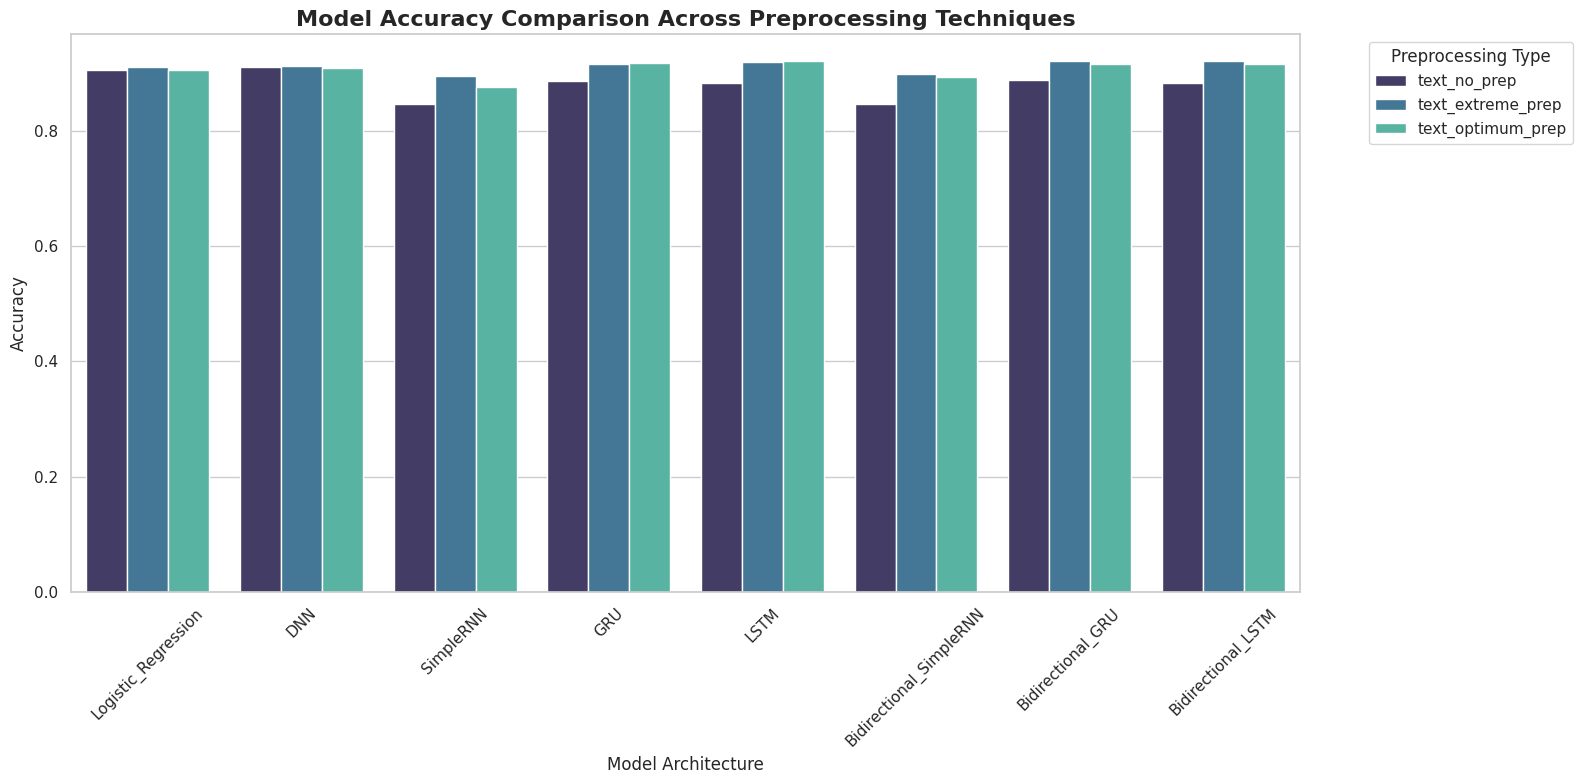

In [ ]:
# Display tabular representation of all model performances sorted by Accuracy
print("--- Tabular Performance Comparison ---")
display(results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))

# Visualize model performance using a bar plot grouped by dataset
plt.figure(figsize=(16, 8))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Dataset', palette='mako')
plt.title('Model Accuracy Comparison Across Preprocessing Techniques', fontsize=16, fontweight='bold')
plt.xlabel('Model Architecture', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Preprocessing Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

🏆 BEST PERFORMING MODEL 🏆
Dataset: text_optimum_prep | Model: LSTM
                        precision    recall  f1-score   support

              Business       0.90      0.87      0.89      3000
Science and Technology       0.88      0.92      0.90      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.94      0.91      0.92      3000

              accuracy                           0.92     12000
             macro avg       0.92      0.92      0.92     12000
          weighted avg       0.92      0.92      0.92     12000



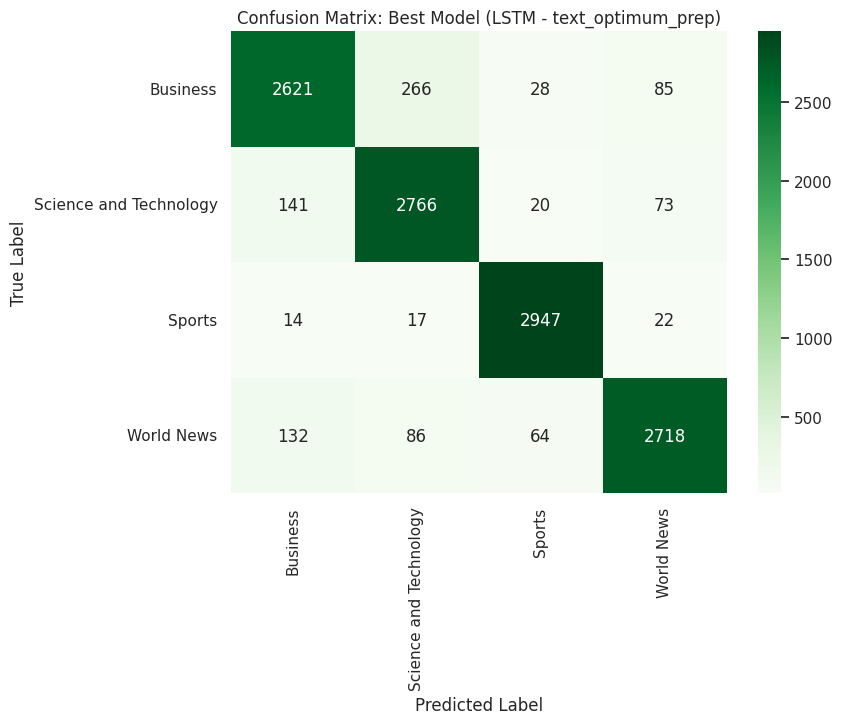


📉 WORST PERFORMING MODEL 📉
Dataset: text_no_prep | Model: Bidirectional_SimpleRNN
                        precision    recall  f1-score   support

              Business       0.86      0.76      0.81      3000
Science and Technology       0.80      0.85      0.82      3000
                Sports       0.84      0.97      0.90      3000
            World News       0.90      0.81      0.85      3000

              accuracy                           0.85     12000
             macro avg       0.85      0.85      0.85     12000
          weighted avg       0.85      0.85      0.85     12000



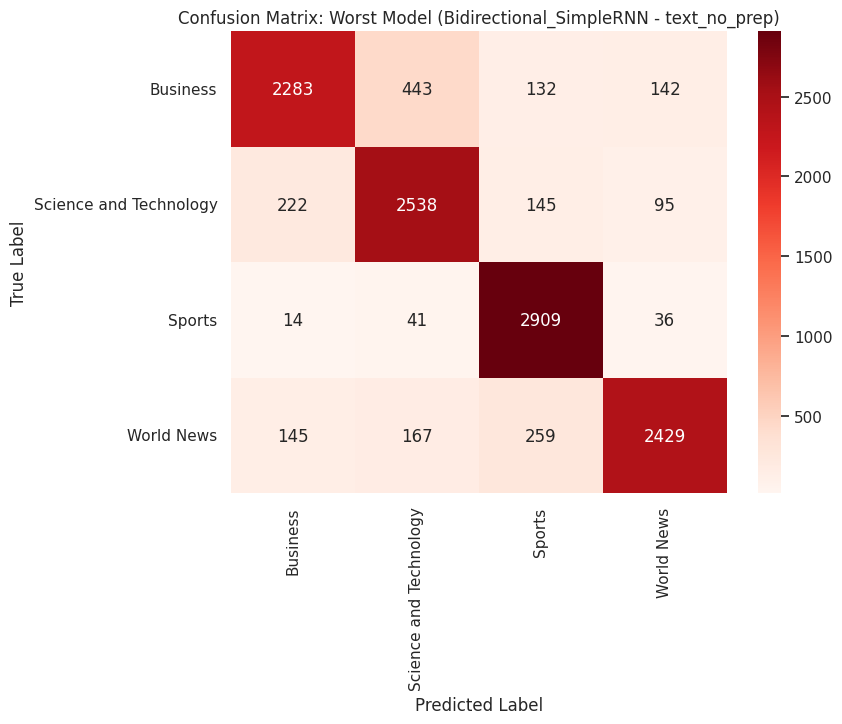

In [ ]:
# Programmatically identify the best and worst models to generate detailed reports
best_run = results_df.loc[results_df['Accuracy'].idxmax()]
worst_run = results_df.loc[results_df['Accuracy'].idxmin()]

# Extract predictions for best and worst models
best_preds = evaluation_results[best_run['Dataset']][best_run['Model']]['predictions']
worst_preds = evaluation_results[worst_run['Dataset']][worst_run['Model']]['predictions']

print("="*60)
print(f"🏆 BEST PERFORMING MODEL 🏆")
print(f"Dataset: {best_run['Dataset']} | Model: {best_run['Model']}")
print("="*60)
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, best_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: Best Model ({best_run['Model']} - {best_run['Dataset']})")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n" + "="*60)
print(f"📉 WORST PERFORMING MODEL 📉")
print(f"Dataset: {worst_run['Dataset']} | Model: {worst_run['Model']}")
print("="*60)
print(classification_report(y_test, worst_preds, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, worst_preds), annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: Worst Model ({worst_run['Model']} - {worst_run['Dataset']})")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()